# ML Step 1: Download ERA5 Meteorological Data

This notebook downloads ERA5 weather data needed for PM2.5/PM10 prediction.

**What is ERA5?**
- Global weather reanalysis dataset from ECMWF
- Covers 1940 to present
- Hourly data at 0.25° resolution (~25 km)

**Variables we need:**
| Variable | Why Needed |
|----------|------------|
| 2m Temperature | Affects atmospheric mixing |
| 2m Dewpoint | To calculate humidity |
| 10m U-wind | East-West wind component |
| 10m V-wind | North-South wind component |
| Surface Pressure | Atmospheric stability |
| Boundary Layer Height | Key for pollution dispersion |

## 1. Setup CDS API

In [ ]:
# Install cdsapi if not already installed
# Uncomment the line below if you need to install
# !pip install cdsapi

In [2]:
import cdsapi
import os
from pathlib import Path

# Your CDS API credentials
CDS_URL = "https://cds.climate.copernicus.eu/api"
CDS_KEY = "4cc98df1-6ba0-46d4-8ab8-4994a12b8396"

# Initialize CDS client with your credentials
client = cdsapi.Client(url=CDS_URL, key=CDS_KEY)

print("CDS API client initialized successfully!")

CDS API client initialized successfully!


In [3]:
# Define output path
output_path = Path(r"C:\projects\aqi_pipline_2026-01-08\02_Input\ERA5")
output_path.mkdir(parents=True, exist_ok=True)

print(f"Output folder: {output_path}")

Output folder: C:\projects\aqi_pipline_2026-01-08\02_Input\ERA5


## 2. Define Download Parameters

We'll download data for:
- **Region:** Abu Dhabi area (same as your pipeline)
- **Period:** 2024 (for training)
- **Resolution:** Hourly (to match ground station data)

In [4]:
# Abu Dhabi region bounding box
# Format: [North, West, South, East]
AREA = [25.5, 51.0, 22.5, 56.5]  # Covers Abu Dhabi emirate

# Variables to download
VARIABLES_SINGLE_LEVEL = [
    '2m_temperature',           # Temperature at 2 meters
    '2m_dewpoint_temperature',  # Dewpoint (for humidity calculation)
    '10m_u_component_of_wind',  # U-wind (east-west)
    '10m_v_component_of_wind',  # V-wind (north-south)
    'surface_pressure',         # Surface pressure
    'boundary_layer_height',    # Planetary boundary layer height
]

# Year and months for training data
YEAR = "2024"
MONTHS = [f"{m:02d}" for m in range(1, 13)]  # 01 to 12

# Hours (all 24 hours for daily matching)
HOURS = [f"{h:02d}:00" for h in range(24)]  # 00:00 to 23:00

print(f"Region: North={AREA[0]}, West={AREA[1]}, South={AREA[2]}, East={AREA[3]}")
print(f"Year: {YEAR}")
print(f"Months: {MONTHS}")
print(f"Variables: {len(VARIABLES_SINGLE_LEVEL)}")
for v in VARIABLES_SINGLE_LEVEL:
    print(f"  - {v}")

Region: North=25.5, West=51.0, South=22.5, East=56.5
Year: 2024
Months: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
Variables: 6
  - 2m_temperature
  - 2m_dewpoint_temperature
  - 10m_u_component_of_wind
  - 10m_v_component_of_wind
  - surface_pressure
  - boundary_layer_height


## 3. Download ERA5 Data

We'll download month by month to avoid timeout issues.

**Expected download time:** 5-15 minutes per month (depends on your internet speed)

In [5]:
def download_era5_month(year, month, variables, area, output_path, client):
    """
    Download ERA5 data for a single month.
    
    Parameters:
    -----------
    year : str - Year to download (e.g., "2024")
    month : str - Month to download (e.g., "01")
    variables : list - List of variable names
    area : list - Bounding box [North, West, South, East]
    output_path : Path - Output directory
    client : cdsapi.Client - CDS API client
    
    Returns:
    --------
    Path to downloaded file
    """
    
    # Output filename
    output_file = output_path / f"ERA5_{year}_{month}.nc"
    
    # Skip if already downloaded
    if output_file.exists():
        print(f"  Already exists: {output_file.name}")
        return output_file
    
    print(f"  Downloading {year}-{month}...")
    
    # All days in month
    days = [f"{d:02d}" for d in range(1, 32)]
    
    # All hours
    hours = [f"{h:02d}:00" for h in range(24)]
    
    # Make the API request
    client.retrieve(
        'reanalysis-era5-single-levels',
        {
            'product_type': 'reanalysis',
            'format': 'netcdf',
            'variable': variables,
            'year': year,
            'month': month,
            'day': days,
            'time': hours,
            'area': area,
        },
        str(output_file)
    )
    
    print(f"  Saved: {output_file.name}")
    return output_file

In [10]:
# Download all months of 2024
print("="*60)
print("DOWNLOADING ERA5 DATA FOR 2024")
print("="*60)
print(f"\nThis will download {len(MONTHS)} months of data.")
print("Estimated time: 1-2 hours total (5-10 min per month)")
print("\nYou can stop and resume later - already downloaded files will be skipped.")
print("="*60)

downloaded_files = []

for i, month in enumerate(MONTHS, 1):
    print(f"\n[{i}/{len(MONTHS)}] Processing {YEAR}-{month}")
    try:
        file_path = download_era5_month(
            year=YEAR,
            month=month,
            variables=VARIABLES_SINGLE_LEVEL,
            area=AREA,
            output_path=output_path,
            client=client
        )
        downloaded_files.append(file_path)
    except Exception as e:
        print(f"  ERROR: {e}")
        print("  Continuing with next month...")

print("\n" + "="*60)
print("DOWNLOAD COMPLETE")
print("="*60)
print(f"\nDownloaded {len(downloaded_files)} files to:")
print(f"  {output_path}")

DOWNLOADING ERA5 DATA FOR 2024

This will download 12 months of data.
Estimated time: 1-2 hours total (5-10 min per month)

You can stop and resume later - already downloaded files will be skipped.

[1/12] Processing 2024-01


2026-01-28 13:23:44,959 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-01-28 13:23:44,960 INFO Request ID is e85f6e93-a4f5-4a21-88d8-eafa0d7bde6e
2026-01-28 13:23:45,106 INFO status has been updated to accepted
2026-01-28 13:23:59,208 INFO status has been updated to running
2026-01-28 13:26:38,690 INFO status has been updated to successful


4066d61969af29d99499861db5f86085.nc:   0%|          | 0.00/2.62M [00:00<?, ?B/s]

  Saved: ERA5_2024_01.nc

[2/12] Processing 2024-02


2026-01-28 13:26:53,867 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-01-28 13:26:53,867 INFO Request ID is 01d663bb-de14-4d09-8739-6b59eb62efb5
2026-01-28 13:26:54,003 INFO status has been updated to accepted
2026-01-28 13:27:03,200 INFO status has been updated to running
2026-01-28 13:27:27,786 INFO status has been updated to accepted
2026-01-28 13:27:45,015 INFO status has been updated to running
2026-01-28 13:29:47,558 INFO status has been updated to successful


...

4c6cdbb97de36dabf17b27b95b961725.nc:   0%|          | 0.00/2.55M [00:00<?, ?B/s]

  Saved: ERA5_2024_11.nc

[12/12] Processing 2024-12


2026-01-28 14:21:19,968 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-01-28 14:21:19,969 INFO Request ID is 72a83e79-05c0-4911-bb98-6c6e1d73d349
2026-01-28 14:21:20,227 INFO status has been updated to accepted
2026-01-28 14:21:28,898 INFO status has been updated to running
2026-01-28 14:25:40,700 INFO status has been updated to successful


d8e83c95c2da54b0ffce381f2fec2715.nc:   0%|          | 0.00/2.63M [00:00<?, ?B/s]

  Saved: ERA5_2024_12.nc

DOWNLOAD COMPLETE

Downloaded 12 files to:
  C:\projects\aqi_pipline_2026-01-08\02_Input\ERA5


## 4. Verify Downloaded Data

Let's check that the data downloaded correctly.

In [6]:
import xarray as xr

# List all downloaded files
nc_files = sorted(output_path.glob("ERA5_*.nc"))

print(f"Found {len(nc_files)} ERA5 files:\n")
for f in nc_files:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name} ({size_mb:.1f} MB)")

Found 12 ERA5 files:

  ERA5_2024_01.nc (2.6 MB)
  ERA5_2024_02.nc (2.5 MB)
  ERA5_2024_03.nc (2.6 MB)
  ERA5_2024_04.nc (2.6 MB)
  ERA5_2024_05.nc (2.7 MB)
  ERA5_2024_06.nc (2.6 MB)
  ERA5_2024_07.nc (2.7 MB)
  ERA5_2024_08.nc (2.7 MB)
  ERA5_2024_09.nc (2.6 MB)
  ERA5_2024_10.nc (2.7 MB)
  ERA5_2024_11.nc (2.6 MB)
  ERA5_2024_12.nc (2.6 MB)


In [7]:
# Open one file to check contents
if nc_files:
    sample_file = nc_files[0]
    print(f"\nChecking: {sample_file.name}\n")
    
    ds = xr.open_dataset(sample_file)
    
    print("Variables:")
    for var in ds.data_vars:
        print(f"  - {var}: {ds[var].dims}, shape={ds[var].shape}")
    
    print(f"\nTime range: {ds.time.values[0]} to {ds.time.values[-1]}")
    print(f"Latitude range: {float(ds.latitude.min()):.2f} to {float(ds.latitude.max()):.2f}")
    print(f"Longitude range: {float(ds.longitude.min()):.2f} to {float(ds.longitude.max()):.2f}")
    
    ds.close()
else:
    print("No files found yet. Run the download cell first.")


Checking: ERA5_2024_01.nc

Variables:
  - t2m: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - d2m: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - u10: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - v10: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - sp: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - blh: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)


AttributeError: 'Dataset' object has no attribute 'time'

In [8]:
import xarray as xr
from pathlib import Path

output_path = Path(r"C:\projects\aqi_pipline_2026-01-08\02_Input\ERA5")
nc_files = sorted(output_path.glob("ERA5_*.nc"))

if nc_files:
    ds = xr.open_dataset(nc_files[0])
    
    print("=== DIMENSIONS ===")
    print(ds.dims)
    
    print("\n=== COORDINATES ===")
    print(list(ds.coords))
    
    print("\n=== VARIABLES ===")
    print(list(ds.data_vars))
    
    print("\n=== FULL STRUCTURE ===")
    print(ds)
    
    ds.close()


=== DIMENSIONS ===
FrozenMappingWarningOnValuesAccess({'valid_time': 744, 'latitude': 13, 'longitude': 23})

=== COORDINATES ===
['number', 'valid_time', 'latitude', 'longitude', 'expver']

=== VARIABLES ===
['t2m', 'd2m', 'u10', 'v10', 'sp', 'blh']

=== FULL STRUCTURE ===
<xarray.Dataset> Size: 5MB
Dimensions:     (valid_time: 744, latitude: 13, longitude: 23)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T23:...
  * latitude    (latitude) float64 104B 25.5 25.25 25.0 ... 23.0 22.75 22.5
  * longitude   (longitude) float64 184B 51.0 51.25 51.5 ... 56.0 56.25 56.5
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 890kB ...
    d2m         (valid_time, latitude, longitude) float32 890kB ...
    u10         (valid_time, latitude, longitude) float32 890kB ...
    v10         (valid_time, latitude, longitude) float32 890kB ...
    sp          (valid_time, l

In [9]:
# Verify downloaded data (using correct coordinate name)
if nc_files:
    ds = xr.open_dataset(nc_files[0])
    
    print("Variables:")
    for var in ds.data_vars:
        print(f"  - {var}: {ds[var].dims}, shape={ds[var].shape}")
    
    print(f"\nTime range: {ds.valid_time.values[0]} to {ds.valid_time.values[-1]}")
    print(f"Latitude range: {float(ds.latitude.min()):.2f} to {float(ds.latitude.max()):.2f}")
    print(f"Longitude range: {float(ds.longitude.min()):.2f} to {float(ds.longitude.max()):.2f}")
    
    print("\n✅ ERA5 data downloaded successfully!")
    ds.close()


Variables:
  - t2m: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - d2m: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - u10: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - v10: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - sp: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)
  - blh: ('valid_time', 'latitude', 'longitude'), shape=(744, 13, 23)

Time range: 2024-01-01T00:00:00.000000000 to 2024-01-31T23:00:00.000000000
Latitude range: 22.50 to 25.50
Longitude range: 51.00 to 56.50

✅ ERA5 data downloaded successfully!


In [10]:
nc_files = sorted(output_path.glob("ERA5_*.nc"))
print(f"Downloaded: {len(nc_files)} / 12 months")
for f in nc_files:
    print(f"  ✅ {f.name}")


Downloaded: 12 / 12 months
  ✅ ERA5_2024_01.nc
  ✅ ERA5_2024_02.nc
  ✅ ERA5_2024_03.nc
  ✅ ERA5_2024_04.nc
  ✅ ERA5_2024_05.nc
  ✅ ERA5_2024_06.nc
  ✅ ERA5_2024_07.nc
  ✅ ERA5_2024_08.nc
  ✅ ERA5_2024_09.nc
  ✅ ERA5_2024_10.nc
  ✅ ERA5_2024_11.nc
  ✅ ERA5_2024_12.nc


## 5. Quick Visualization (Optional)

Let's visualize one variable to confirm data looks correct.

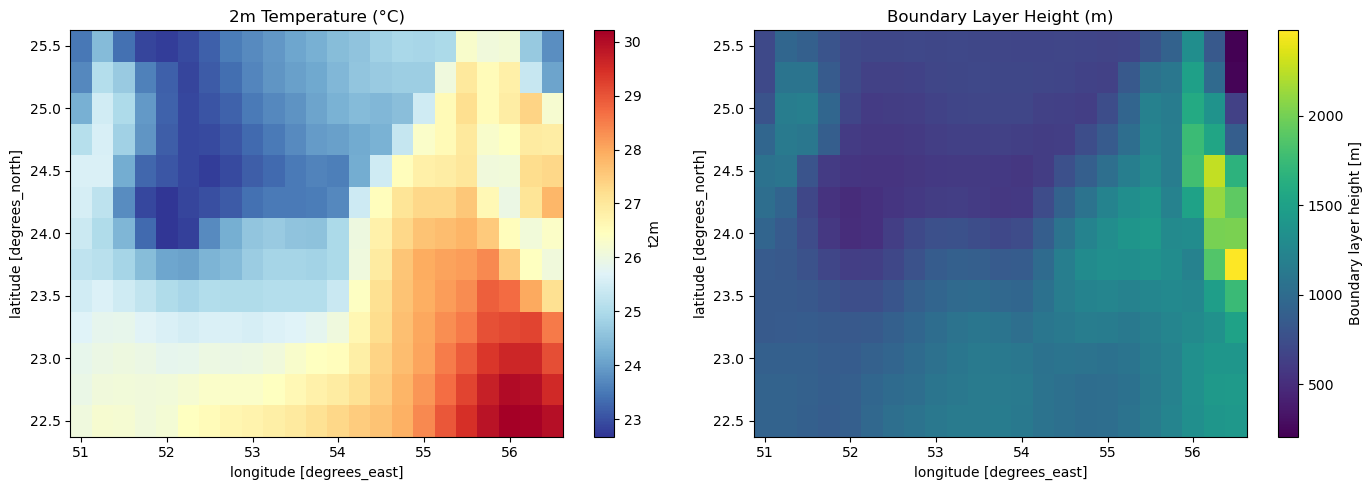


✅ Data looks good! Ready for next step.


In [13]:
import matplotlib.pyplot as plt

if nc_files:
    ds = xr.open_dataset(nc_files[0])
    
    # Plot temperature for first timestep
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Temperature (convert from Kelvin to Celsius)
    temp_c = ds['t2m'].isel(valid_time=12) - 273.15
    temp_c.plot(ax=axes[0], cmap='RdYlBu_r')
    axes[0].set_title('2m Temperature (°C)')
    
    # Boundary Layer Height
    ds['blh'].isel(valid_time=12).plot(ax=axes[1], cmap='viridis')
    axes[1].set_title('Boundary Layer Height (m)')
    
    plt.tight_layout()
    plt.show()
    
    ds.close()
    print("\n✅ Data looks good! Ready for next step.")
else:
    print("No files to visualize yet.")


## Summary

**What we downloaded:**
- ERA5 reanalysis data for 2024
- 6 weather variables
- Hourly resolution
- Abu Dhabi region

**Next Step:**
- `ML_02_Prepare_Training_Data.ipynb` - Match satellite + weather data at ground station locations

**Files created:**
```
02_Input/ERA5/
├── ERA5_2024_01.nc
├── ERA5_2024_02.nc
├── ...
└── ERA5_2024_12.nc
```